In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pickle import TRUE
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.metrics import Metric
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
from deap import base as deap_base, creator, tools, algorithms
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [97]:
base = pd.read_csv('C:/Users/mathg/OneDrive/Documents/Diretório/Projetos no VSCode/MPU e TCC/baseDef.csv', encoding='ISO-8859-1')    # carregar a base
target = base['Devadido']
base1 = base.drop(columns=["Devadido"])
base1 = base1.drop(columns=["Nt.Final"])
base1 = base1.drop(columns=["Nt.Média"])
#base1['Nt.Média'] = base1['Nt.Média'] / 10


X_treino, X_teste, y_treino, y_teste = train_test_split(base1, target, test_size=0.2, random_state=42)
feature_names = X_treino.columns
X_treino = X_treino.to_numpy()
X_teste = X_teste.to_numpy()
y_treino = y_treino.to_numpy()
y_teste = y_teste.to_numpy()


# caso queira normalizar os dados
# scaler = StandardScaler()
# X_treino_scaled = scaler.fit_transform(X_treino)
# X_teste_scaled = scaler.transform(X_teste)

In [84]:
scaler = StandardScaler()
X_teste_scaled = scaler.fit_transform(X_teste)

In [59]:
hiperPModel  = {                         # lista que será otimizada com o AG
    'n_d': (20,32),
    'n_a': (16,32),
    'n_steps': (3,6),
    'gamma': ( 1.0, 2.0),
    'lambda_sparse': (0.1,0.2)
}

HiperP = {                         # lista que não será otimizada com o AG
    'max_epochs': (80),
    'patience': (15),
    'generations': (5),
    'elitism': (1),
    'population': (5)
}

In [60]:
def fitness_function(individual):
    n_d, n_a, n_steps, gamma, lambda_sparse = individual

    # Criar e treinar o modelo
    modelo = TabNetClassifier(
        n_d=int(n_d),
        n_a=int(n_a),
        n_steps=int(n_steps),
        gamma=gamma,
        lambda_sparse=lambda_sparse,
    )

    modelo.fit(
        X_train=X_treino, y_train=y_treino,
        eval_metric=['accuracy'], max_epochs=HiperP['max_epochs'] , patience=HiperP['patience'],
        batch_size=250, compute_importance=True
    )

    # Fazer previsões no conjunto de validação
    y_prev_val = modelo.predict(X_treino)
    accuracy = accuracy_score(y_treino, y_prev_val)

    # Salvar a importância das variáveis
    global feature_importances
    feature_importances = modelo.feature_importances_

    # Retornar acurácia
    return accuracy,


In [61]:
creator.create('FitnessMax', deap_base.Fitness, weights=(1.0,))
creator.create('Individual', list, fitness=creator.FitnessMax)

toolbox = deap_base.Toolbox()
toolbox.register("attr_n_d", np.random.randint, hiperPModel["n_d"][0], hiperPModel["n_d"][1])
toolbox.register("attr_n_a", np.random.randint, hiperPModel["n_a"][0], hiperPModel["n_a"][1])
toolbox.register("attr_n_steps", np.random.randint, hiperPModel["n_steps"][0], hiperPModel["n_steps"][1])
toolbox.register("attr_gamma", np.random.uniform, hiperPModel["gamma"][0], hiperPModel["gamma"][1])
toolbox.register("attr_lambda_sparse", np.random.uniform, hiperPModel["lambda_sparse"][0], hiperPModel["lambda_sparse"][1])

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_n_d, toolbox.attr_n_a, toolbox.attr_n_steps,
                  toolbox.attr_gamma, toolbox.attr_lambda_sparse), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", fitness_function)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# def main():
#     np.random.seed(42)
#     population = toolbox.population(n=20)
#     generations = 10
#     elitism = 2  # Número de indivíduos a serem preservados

#     for gen in range(generations):
#         # Avaliar os indivíduos que ainda não foram avaliados
#         invalid_ind = [ind for ind in population if not ind.fitness.valid]
#         fitnesses = list(map(toolbox.evaluate, invalid_ind))
#         for ind, fit in zip(invalid_ind, fitnesses):
#             ind.fitness.values = fit

#         # Selecionar os melhores indivíduos (elitismo)
#         elites = tools.selBest(population, k=elitism)

#         # Seleção, cruzamento e mutação
#         offspring = toolbox.select(population, len(population) - elitism)
#         offspring = list(map(toolbox.clone, offspring))
#         for child1, child2 in zip(offspring[::2], offspring[1::2]):
#             if np.random.random() < 0.8:  # Taxa de crossover
#                 toolbox.mate(child1, child2)
#                 del child1.fitness.values
#                 del child2.fitness.values

#         for mutant in offspring:
#             if np.random.random() < 0.2:  # Taxa de mutação
#                 toolbox.mutate(mutant)
#                 del mutant.fitness.values

#         # Adicionar os elites diretamente à próxima geração
#         population[:] = elites + offspring

#         # Imprimir estatísticas da geração atual
#         fits = [ind.fitness.values[0] for ind in population]
#         print(f"Geração {gen+1}: Melhor fitness = {max(fits):.2f}")

#     # Melhor indivíduo final
#     best_individual = tools.selBest(population, k=1)[0]
#     print(f"\nMelhores Hiperparâmetros: {best_individual}")
#     print(f"Acurácia: {best_individual.fitness.values[0]:.2f}")

#     # (Opcional) Importância das Features, conforme o código original
#     global feature_importances
#     df_importances = pd.DataFrame({
#         "Feature": feature_names,
#         "Importance": feature_importances
#     }).sort_values(by="Importance", ascending=False)

#     print("\nImportância das Features:")
#     print(df_importances)

#     # Visualizar gráfico de importância das features
#     plt.figure(figsize=(10, 6))
#     plt.barh(df_importances["Feature"], df_importances["Importance"], color="skyblue")
#     plt.xlabel("Importância")
#     plt.ylabel("Feature")
#     plt.title("Importância das Features (TabNet)")
#     plt.gca().invert_yaxis()
#     plt.show()

# if __name__ == "__main__":
#     main()


c:\Users\mathg\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\mathg\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.02846 |  0:00:00s
epoch 1  | loss: 0.86373 |  0:00:00s
epoch 2  | loss: 0.7914  |  0:00:01s
epoch 3  | loss: 0.75913 |  0:00:01s
epoch 4  | loss: 0.73107 |  0:00:02s
epoch 5  | loss: 0.71884 |  0:00:02s
epoch 6  | loss: 0.70992 |  0:00:03s
epoch 7  | loss: 0.69554 |  0:00:03s
epoch 8  | loss: 0.69593 |  0:00:04s
epoch 9  | loss: 0.68577 |  0:00:04s
epoch 10 | loss: 0.68141 |  0:00:05s
epoch 11 | loss: 0.67961 |  0:00:05s
epoch 12 | loss: 0.67602 |  0:00:06s
epoch 13 | loss: 0.67023 |  0:00:06s
epoch 14 | loss: 0.66439 |  0:00:06s
epoch 15 | loss: 0.66178 |  0:00:07s
epoch 16 | loss: 0.65779 |  0:00:07s
epoch 17 | loss: 0.65826 |  0:00:08s
epoch 18 | loss: 0.65704 |  0:00:08s
epoch 19 | loss: 0.6505  |  0:00:08s
epoch 20 | loss: 0.64624 |  0:00:09s
epoch 21 | loss: 0.65459 |  0:00:09s
epoch 22 | loss: 0.65814 |  0:00:10s
epoch 23 | loss: 0.65042 |  0:00:10s
epoch 24 | loss: 0.64388 |  0:00:11s
epoch 25 | loss: 0.65294 |  0:00:12s
epoch 26 | loss: 0.64963 |  0:00:13s
e

c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.22333 |  0:00:00s
epoch 1  | loss: 0.83647 |  0:00:01s
epoch 2  | loss: 0.7819  |  0:00:02s
epoch 3  | loss: 0.75292 |  0:00:03s
epoch 4  | loss: 0.73151 |  0:00:04s
epoch 5  | loss: 0.71714 |  0:00:05s
epoch 6  | loss: 0.70071 |  0:00:05s
epoch 7  | loss: 0.69913 |  0:00:06s
epoch 8  | loss: 0.69188 |  0:00:07s
epoch 9  | loss: 0.6863  |  0:00:08s
epoch 10 | loss: 0.68282 |  0:00:09s
epoch 11 | loss: 0.6768  |  0:00:09s
epoch 12 | loss: 0.67504 |  0:00:10s
epoch 13 | loss: 0.67161 |  0:00:11s
epoch 14 | loss: 0.67255 |  0:00:12s
epoch 15 | loss: 0.66828 |  0:00:13s
epoch 16 | loss: 0.6703  |  0:00:14s
epoch 17 | loss: 0.66401 |  0:00:15s
epoch 18 | loss: 0.66558 |  0:00:15s
epoch 19 | loss: 0.66279 |  0:00:16s
epoch 20 | loss: 0.66675 |  0:00:17s
epoch 21 | loss: 0.66174 |  0:00:18s
epoch 22 | loss: 0.65681 |  0:00:19s
epoch 23 | loss: 0.65717 |  0:00:20s
epoch 24 | loss: 0.65185 |  0:00:20s
epoch 25 | loss: 0.65298 |  0:00:21s
epoch 26 | loss: 0.65247 |  0:00:22s
e

c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


...

epoch 0  | loss: 0.13885 |  0:00:00s
epoch 1  | loss: -0.06736|  0:00:00s
epoch 2  | loss: -0.21511|  0:00:01s
epoch 3  | loss: -0.33818|  0:00:01s
epoch 4  | loss: -0.46126|  0:00:02s
epoch 5  | loss: -0.52086|  0:00:02s
epoch 6  | loss: -0.60364|  0:00:03s
epoch 7  | loss: -0.66792|  0:00:03s
epoch 8  | loss: -0.69484|  0:00:04s
epoch 9  | loss: -0.75407|  0:00:04s
epoch 10 | loss: -0.81042|  0:00:05s
epoch 11 | loss: -0.85676|  0:00:05s
epoch 12 | loss: -0.81273|  0:00:06s
epoch 13 | loss: -0.85924|  0:00:06s
epoch 14 | loss: -0.89761|  0:00:07s
epoch 15 | loss: -0.89616|  0:00:08s
epoch 16 | loss: -0.91793|  0:00:08s
epoch 17 | loss: -0.92443|  0:00:09s
epoch 18 | loss: -0.9248 |  0:00:09s
epoch 19 | loss: -0.94941|  0:00:10s
epoch 20 | loss: -0.96086|  0:00:10s
epoch 21 | loss: -0.9442 |  0:00:11s
epoch 22 | loss: -0.96549|  0:00:11s
epoch 23 | loss: -0.93739|  0:00:12s
epoch 24 | loss: -0.96708|  0:00:12s
epoch 25 | loss: -0.96748|  0:00:13s
epoch 26 | loss: -0.97751|  0:00:13s
e

c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.13885 |  0:00:00s
epoch 1  | loss: -0.06736|  0:00:01s
epoch 2  | loss: -0.21511|  0:00:01s
epoch 3  | loss: -0.33818|  0:00:02s
epoch 4  | loss: -0.46126|  0:00:02s
epoch 5  | loss: -0.52086|  0:00:03s
epoch 6  | loss: -0.60364|  0:00:03s
epoch 7  | loss: -0.66792|  0:00:04s
epoch 8  | loss: -0.69484|  0:00:04s
epoch 9  | loss: -0.75407|  0:00:05s
epoch 10 | loss: -0.81042|  0:00:05s
epoch 11 | loss: -0.85676|  0:00:06s
epoch 12 | loss: -0.81273|  0:00:06s
epoch 13 | loss: -0.85924|  0:00:07s
epoch 14 | loss: -0.89761|  0:00:07s
epoch 15 | loss: -0.89616|  0:00:08s
epoch 16 | loss: -0.91793|  0:00:08s
epoch 17 | loss: -0.92443|  0:00:09s
epoch 18 | loss: -0.9248 |  0:00:09s
epoch 19 | loss: -0.94941|  0:00:10s
epoch 20 | loss: -0.96086|  0:00:10s
epoch 21 | loss: -0.9442 |  0:00:11s
epoch 22 | loss: -0.96549|  0:00:11s
epoch 23 | loss: -0.93739|  0:00:12s
epoch 24 | loss: -0.96708|  0:00:13s
epoch 25 | loss: -0.96748|  0:00:13s
epoch 26 | loss: -0.97751|  0:00:14s
e

c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.13885 |  0:00:00s
epoch 1  | loss: -0.06736|  0:00:01s
epoch 2  | loss: -0.21511|  0:00:01s
epoch 3  | loss: -0.33818|  0:00:02s
epoch 4  | loss: -0.46126|  0:00:02s
epoch 5  | loss: -0.52086|  0:00:03s
epoch 6  | loss: -0.60364|  0:00:03s
epoch 7  | loss: -0.66792|  0:00:04s
epoch 8  | loss: -0.69484|  0:00:04s
epoch 9  | loss: -0.75407|  0:00:05s
epoch 10 | loss: -0.81042|  0:00:05s
epoch 11 | loss: -0.85676|  0:00:06s
epoch 12 | loss: -0.81273|  0:00:06s
epoch 13 | loss: -0.85924|  0:00:07s
epoch 14 | loss: -0.89761|  0:00:07s
epoch 15 | loss: -0.89616|  0:00:08s
epoch 16 | loss: -0.91793|  0:00:09s
epoch 17 | loss: -0.92443|  0:00:09s
epoch 18 | loss: -0.9248 |  0:00:10s
epoch 19 | loss: -0.94941|  0:00:10s
epoch 20 | loss: -0.96086|  0:00:11s
epoch 21 | loss: -0.9442 |  0:00:11s
epoch 22 | loss: -0.96549|  0:00:12s
epoch 23 | loss: -0.93739|  0:00:12s
epoch 24 | loss: -0.96708|  0:00:13s
epoch 25 | loss: -0.96748|  0:00:14s
epoch 26 | loss: -0.97751|  0:00:14s
e

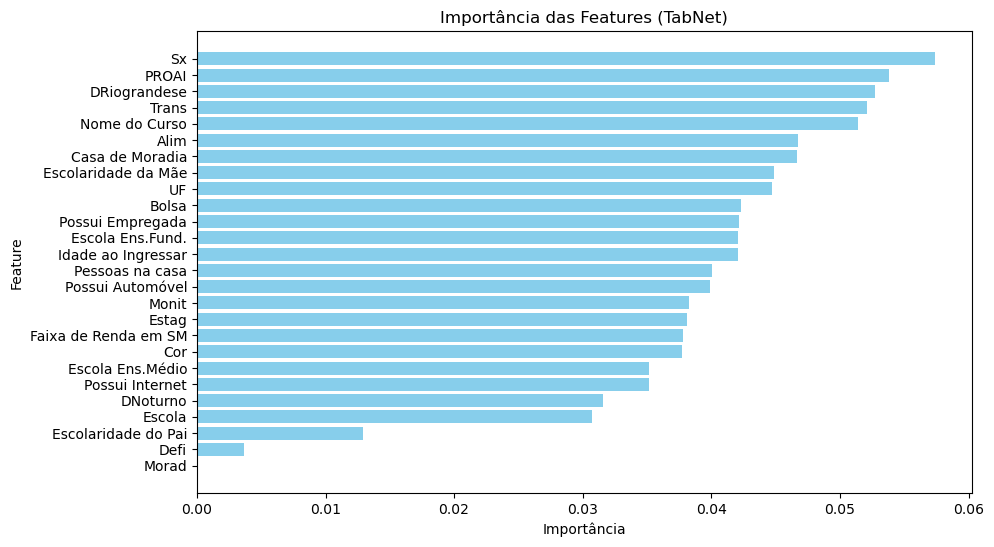

In [62]:
def main():
    np.random.seed(42)
    population = toolbox.population(n=HiperP['population'])
    generations = HiperP['generations']
    elitism = HiperP['elitism']  # Número de indivíduos a serem preservados

    for gen in range(generations):
        # Avaliar os indivíduos que ainda não foram avaliados
        invalid_ind = [ind for ind in population if not ind.fitness.valid]
        fitnesses = list(map(toolbox.evaluate, invalid_ind))
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Selecionar os melhores indivíduos (elitismo)
        elites = tools.selBest(population, k=elitism)

        # Seleção, cruzamento e mutação
        offspring = toolbox.select(population, len(population) - elitism)
        offspring = list(map(toolbox.clone, offspring))
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if np.random.random() < 0.7:  # Taxa de crossover
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if np.random.random() < 0.3:  # Taxa de mutação
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Avaliar os indivíduos que ainda não foram avaliados
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = list(map(toolbox.evaluate, invalid_ind))
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Adicionar os elites diretamente à próxima geração
        population[:] = elites + offspring

        # Imprimir estatísticas da geração atual
        fits = [ind.fitness.values[0] for ind in population]
        print(f"Geração {gen+1}: Melhor fitness = {max(fits):.2f}")

    # Melhor indivíduo final
    best_individual = tools.selBest(population, k=1)[0]
    print(f"\nMelhores Hiperparâmetros: {best_individual}")
    print(f"Acurácia: {best_individual.fitness.values[0]:.2f}")

    # Visualizar gráfico de importância das features (opcional)
    if 'feature_importances' in globals() and feature_importances is not None:
        df_importances = pd.DataFrame({
            "Feature": feature_names,
            "Importance": feature_importances
        }).sort_values(by="Importance", ascending=False)

        print("\nImportância das Features:")
        print(df_importances)

        plt.figure(figsize=(10, 6))
        plt.barh(df_importances["Feature"], df_importances["Importance"], color="skyblue")
        plt.xlabel("Importância")
        plt.ylabel("Feature")
        plt.title("Importância das Features (TabNet)")
        plt.gca().invert_yaxis()
        plt.show()

if __name__ == "__main__":
    main()


In [157]:
# Criar o modelo com melhores hiperparâmetros
modeloMelhor = TabNetClassifier(
  n_d=26,
  n_a=19,
  n_steps=3,
  gamma=1.1579068036418554,
  lambda_sparse=0.5396931992595257
)

modeloMelhor.fit(
  X_train=X_treino, y_train=y_treino,
  eval_metric=['accuracy'], max_epochs=100, patience=20,
  batch_size=250, compute_importance=True
)

c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
c:\Users\mathg\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.28909 |  0:00:00s
epoch 1  | loss: 1.02852 |  0:00:00s
epoch 2  | loss: 0.89284 |  0:00:01s
epoch 3  | loss: 0.81329 |  0:00:01s
epoch 4  | loss: 0.7786  |  0:00:02s
epoch 5  | loss: 0.75285 |  0:00:02s
epoch 6  | loss: 0.74663 |  0:00:03s
epoch 7  | loss: 0.72653 |  0:00:04s
epoch 8  | loss: 0.71834 |  0:00:04s
epoch 9  | loss: 0.70598 |  0:00:05s
epoch 10 | loss: 0.69747 |  0:00:05s
epoch 11 | loss: 0.69628 |  0:00:06s
epoch 12 | loss: 0.68903 |  0:00:06s
epoch 13 | loss: 0.69253 |  0:00:07s
epoch 14 | loss: 0.68228 |  0:00:07s
epoch 15 | loss: 0.68657 |  0:00:08s
epoch 16 | loss: 0.68634 |  0:00:08s
epoch 17 | loss: 0.68654 |  0:00:09s
epoch 18 | loss: 0.68183 |  0:00:09s
epoch 19 | loss: 0.68444 |  0:00:09s
epoch 20 | loss: 0.68075 |  0:00:10s
epoch 21 | loss: 0.68114 |  0:00:10s
epoch 22 | loss: 0.67752 |  0:00:11s
epoch 23 | loss: 0.67771 |  0:00:11s
epoch 24 | loss: 0.67576 |  0:00:12s
epoch 25 | loss: 0.67831 |  0:00:12s
epoch 26 | loss: 0.67433 |  0:00:13s
e

In [158]:
# Prever os rótulos do conjunto de teste
preds = modeloMelhor.predict(X_teste)

# Calcular a acurácia
accuracy = accuracy_score(y_teste, preds)
print(f"Acurácia no conjunto de teste: {accuracy:.4f}")

# Exibir o relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_teste, preds))

# Exibir a matriz de confusão
print("\nMatriz de Confusão:")
conf_matrix = confusion_matrix(y_teste, preds)
print(conf_matrix)

Acurácia no conjunto de teste: 0.6143

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.56      0.22      0.32       346
           1       0.62      0.88      0.73       507

    accuracy                           0.61       853
   macro avg       0.59      0.55      0.52       853
weighted avg       0.60      0.61      0.56       853


Matriz de Confusão:
[[ 77 269]
 [ 60 447]]


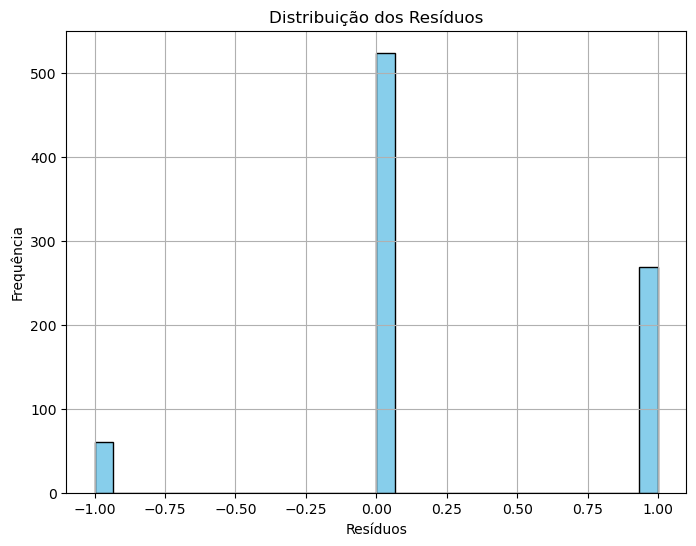

In [153]:
residuals = preds - y_teste

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos")
plt.grid()
plt.show()


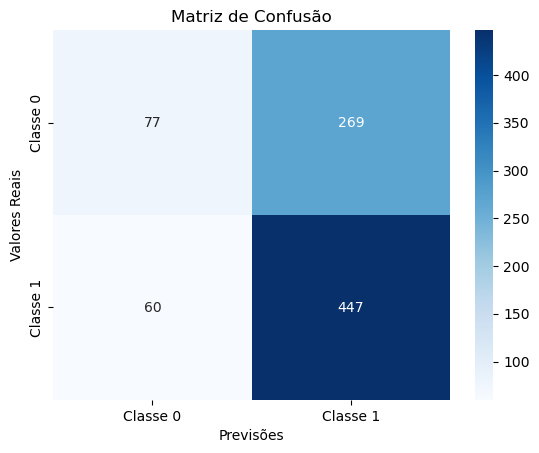

In [159]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = modeloMelhor.predict(X_teste)  # Previsões do modelo
y_true = y_teste  # Labels reais

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Classe 0", "Classe 1"], yticklabels=["Classe 0", "Classe 1"])
plt.title("Matriz de Confusão")
plt.xlabel("Previsões")
plt.ylabel("Valores Reais")
plt.show()

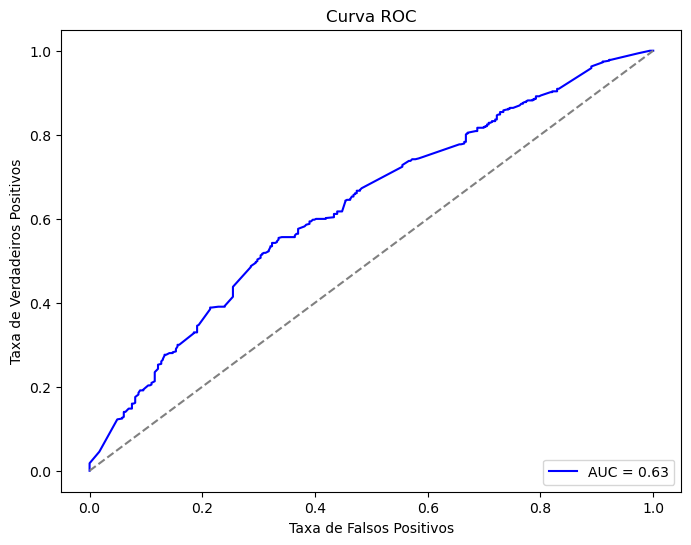

In [160]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, modeloMelhor.predict_proba(X_teste)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("Curva ROC")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.legend(loc="lower right")
plt.show()


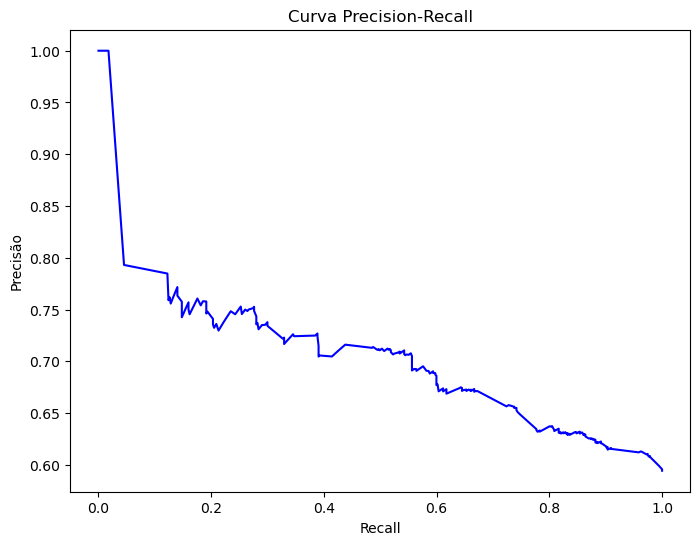

In [161]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, modeloMelhor.predict_proba(X_teste)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b')
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.show()


In [162]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Acurácia
accuracy = accuracy_score(y_true, y_pred)
# Precisão
precision = precision_score(y_true, y_pred)
# Recall
recall = recall_score(y_true, y_pred)
# F1-Score
f1 = f1_score(y_true, y_pred)

print(f"Acurácia: {accuracy:.2f}")
print(f"Precisão: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Acurácia: 0.61
Precisão: 0.62
Recall: 0.88
F1-Score: 0.73


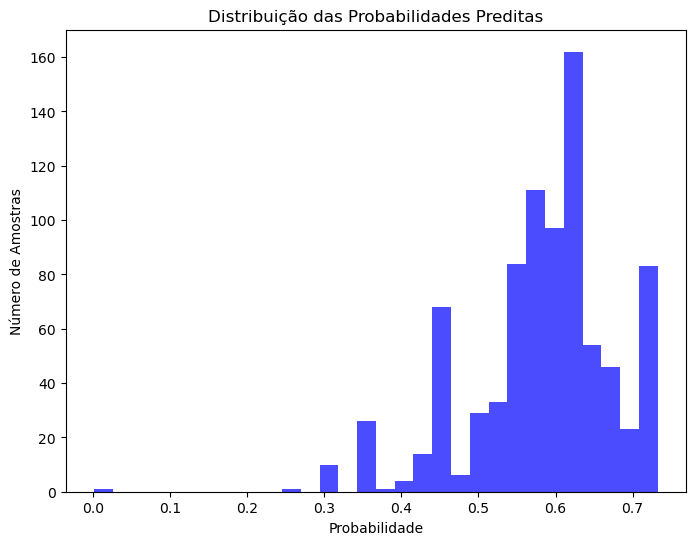

In [163]:
y_pred_proba = modeloMelhor.predict_proba(X_teste)[:, 1]  # Probabilidade da classe positiva

plt.figure(figsize=(8, 6))
plt.hist(y_pred_proba, bins=30, color='b', alpha=0.7)
plt.title("Distribuição das Probabilidades Preditas")
plt.xlabel("Probabilidade")
plt.ylabel("Número de Amostras")
plt.show()
